In [1]:
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("ATLAS")
import os
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator
import os
import config
import utils as ut
import json

2026-05-19 17:00:45.874026: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-19 17:00:45.902754: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-19 17:00:45.903189: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-19 17:00:46.426943: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# function to perform analysis of efficiency results
def analyzeResults(pt, pt_bins, results):
    acc0, acc0_errs = [], [] # High pT accuracy
    acc1, acc1_errs = [], [] # Low pT negative accuracy
    acc2, acc2_errs = [], [] # Low pT positive accuracy
    for acc, acc_errs, label in zip([acc0, acc1, acc2], [acc0_errs, acc1_errs, acc2_errs], [0, 1, 2]):
        # loop over the pT bins
        for i in range(len(pt_bins) - 1):
            in_bin_extracted = (pt >= pt_bins[i]) & (pt < pt_bins[i+1])
            N = np.sum(in_bin_extracted)
            if np.sum(in_bin_extracted) > 0:
                # Check how many were correctly labeled correctly
                predicted_label = (results[in_bin_extracted] == label)
                npass = np.sum(predicted_label)
                eff = npass / N
                eff_err = efficiency_error(eff, N)
                # save
                acc.append(eff)
                acc_errs.append(eff_err)
            else:
                acc.append(0)
                acc_errs.append(0)
    
    # Calculate performance metrics
    high_pT = (pt > 2)
    low_pT = (pt <= 2)
    high_pT_pred = (results == 0)
    low_pT_pred = (results == 1) | (results == 2)
    signal_efficiency = np.sum(high_pT & high_pT_pred) / np.sum(high_pT)
    background_rejection = np.sum(low_pT & low_pT_pred) / np.sum(low_pT)
    data_reduction = np.sum(low_pT_pred) / len(pt)
    return np.array(acc0), np.array(acc0_errs), np.array(acc1), np.array(acc1_errs), np.array(acc2), np.array(acc2_errs), signal_efficiency, background_rejection, data_reduction

# Calculate the difference in event-by-event yprofiles and quantify the difference by summing across all 16 rows of the yprofile for each event
def yprofile_difference(pt, pt_bins, results_true, results):
    difference = []
    difference_err = []
    # loop over the pT bins
    for i in range(len(pt_bins) - 1):
        in_bin_extracted = (pt >= pt_bins[i]) & (pt < pt_bins[i+1])
        N = np.sum(in_bin_extracted)
        if N > 0:
            # Extract the yprofiles for the events in the current bin
            true_profiles = results_true[in_bin_extracted]  # Shape: (N, 16)
            predicted_profiles = results[in_bin_extracted]  # Shape: (N, 16)
            # Compute the event-by-event difference and sum across 16 rows
            # event_differences = np.sum(np.abs(true_profiles - predicted_profiles), axis=1)  # Shape: (N,) # Remove abs because scan-chain yprofile can be lower than the true yprofile (DS, 6May26)
            event_differences = np.sum(true_profiles - predicted_profiles, axis=1)

            # Average the summed differences for the current bin
            average_difference = np.mean(event_differences)
            difference.append(average_difference)
            difference_err.append(0)
        else:
            # If no events in the bin, append 0
            difference.append(0)
            difference_err.append(0)

    return difference

# efficiency error calculation
def efficiency_error(eff, N):
    ''' 
    See section 2.2.1 https://lss.fnal.gov/archive/test-tm/2000/fermilab-tm-2286-cd.pdf
    eff = estimate of the efficiency
    N = sample size
    '''
    return np.sqrt(eff * (1 - eff) / N)

## Load DNN results and y-profiles
Once the readout.csv is produced, it is passed to CMSPIX_DAQ/lab_analysis/dynamic_parseDNNresults.py to obtain final_results.npy (DNN results in 0/1/2 format).

In [3]:
confs = config.confs_TB1Chip23_HLEVtuned #config.confs_TB1Chip23_BDtuning4 #config.confs_TB1_BDtuning4_TS20 # confs_TB1_ABtuning # confs_TB1_BDtuning # 

save_dir = 'newFNALmodels/'
# save_dir = 'tmp_Noise2400e-/newFNALmodels/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
suffix = ""
# suffix = 'model1'

datadir = f"/asic/projects/C/CMS_PIX_28/dshekar/filter/model_pipeline/tmp_16x16_hlevOptimized"
# datadir = f"/asic/projects/C/CMS_PIX_28/dshekar/filter/model_pipeline/tmp_16x16_centeredIncidence"
# datadir = f"/asic/projects/C/CMS_PIX_28/dshekar/filter/model_pipeline/tmp_21x13"

for conf in confs:
    dir = os.path.join(datadir, "_".join(map(str, conf["qm_charge_levels"])))
    conf["pt"] = np.load(os.path.join(dir, "pts.npy"))
    conf["ylocals"] = np.load(os.path.join(dir, "ylocals.npy"))
    conf["clslabels"] = np.load(os.path.join(dir, "clslabels.npy"))
    conf["yprofiles"] = np.load(os.path.join(dir, "yprofiles.npy"))
    conf["keras_predictions"] = np.load(os.path.join(dir, "keras_predictions.npy"))
    conf["keras_predictions"] = np.argmax(conf["keras_predictions"], axis=1)
    conf["qkeras_predictions"] = np.load(os.path.join(dir, "qkeras_predictions.npy"))
    conf["qkeras_predictions"] = np.argmax(conf["qkeras_predictions"], axis=1)
    # conf["asic_predictions"] = np.load(conf["asic_path"])
    if conf["asic_path"].endswith('.csv'):
        # Trying to plot the dnn_RTL_out.csv to see if
        temp = pd.read_csv(conf["asic_path"], header=None).values.flatten()  # 1D array
        # temp = np.append(temp, 3)  # append a single value
        conf["asic_predictions"] = temp
    elif conf["asic_path"].endswith('.npy'):
        conf["asic_predictions"] = np.load(conf["asic_path"])
    conf["asic_yprofiles"] = np.loadtxt(conf["asic_yprofiles_path"], delimiter=",")
    conf["noise_yprofile"] = []
    print(conf["asic_predictions"].shape)

(169607,)
(169607,)
(169607,)


## Plot y-profile distribution

Text(1, 0, 'y-local [mm]')

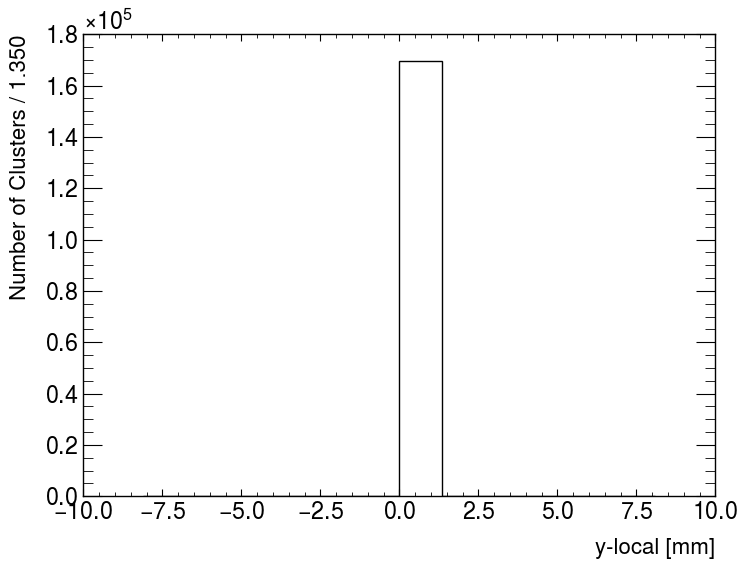

In [4]:
# plot ylocals
fig, ax = plt.subplots(figsize=(8,6))
bins = np.linspace(-8.1, 8.1, 13)
bw = bins[1] - bins[0]
ax.hist(confs[0]["ylocals"], bins=bins, histtype='step', color='black')
ax.set_ylabel(f"Number of Clusters / {bw:.3f}", fontsize=16)
ax.set_xlabel("y-local [mm]", fontsize=16)


## Accuracy results of the DNN


Dataset:  [400, 800, 1200] , size of asic results =  (169607,) , total size of dataset =  169607
Truth level signal efficiency = 100.00%, background rejection = 22.48%, data reduction = 22.48%
Keras signal efficiency = 94.81%, background rejection = 41.07%, data reduction = 41.07%
QKeras signal efficiency = 93.83%, background rejection = 37.83%, data reduction = 37.83%
ASIC signal efficiency = 70.67%, background rejection = 32.91%, data reduction = 32.91%

Dataset:  [700, 1400, 2100] , size of asic results =  (169607,) , total size of dataset =  169607
Truth level signal efficiency = 100.00%, background rejection = 22.48%, data reduction = 22.48%
Keras signal efficiency = 94.17%, background rejection = 41.60%, data reduction = 41.60%
QKeras signal efficiency = 93.93%, background rejection = 39.39%, data reduction = 39.39%
ASIC signal efficiency = 83.41%, background rejection = 43.27%, data reduction = 43.27%

Dataset:  [1000, 2000, 3000] , size of asic results =  (169607,) , total siz

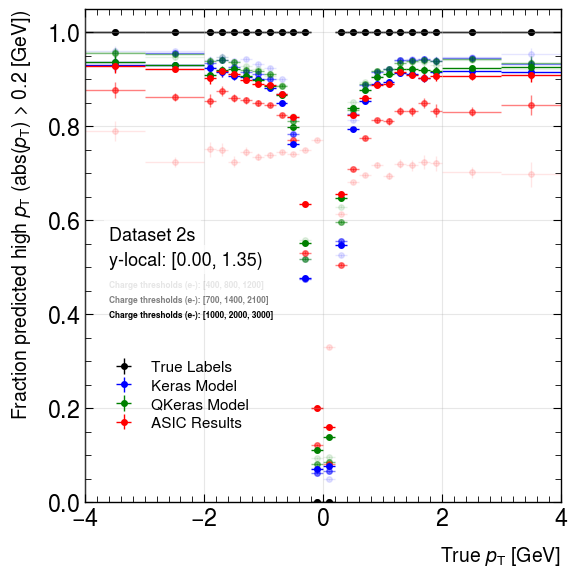


Dataset:  [400, 800, 1200] , size of asic results =  (169607,) , total size of dataset =  169607
Truth level signal efficiency = 100.00%, background rejection = 22.48%, data reduction = 22.48%
Keras signal efficiency = 94.81%, background rejection = 41.07%, data reduction = 41.07%
QKeras signal efficiency = 93.83%, background rejection = 37.83%, data reduction = 37.83%
ASIC signal efficiency = 70.67%, background rejection = 32.91%, data reduction = 32.91%

Dataset:  [700, 1400, 2100] , size of asic results =  (169607,) , total size of dataset =  169607
Truth level signal efficiency = 100.00%, background rejection = 22.48%, data reduction = 22.48%
Keras signal efficiency = 94.17%, background rejection = 41.60%, data reduction = 41.60%
QKeras signal efficiency = 93.93%, background rejection = 39.39%, data reduction = 39.39%
ASIC signal efficiency = 83.41%, background rejection = 43.27%, data reduction = 43.27%

Dataset:  [1000, 2000, 3000] , size of asic results =  (169607,) , total siz

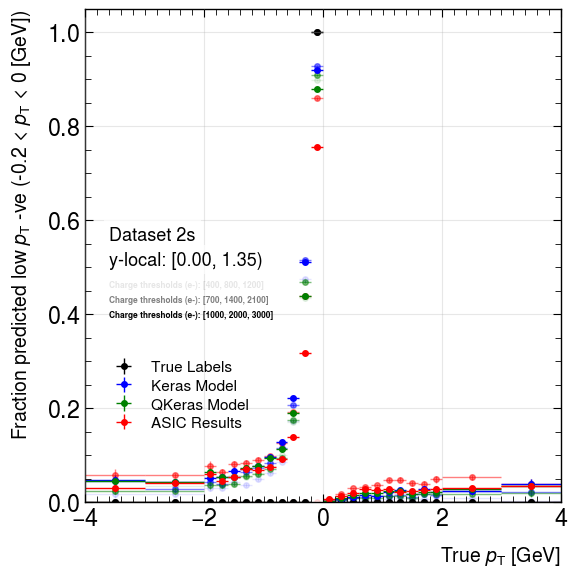


Dataset:  [400, 800, 1200] , size of asic results =  (169607,) , total size of dataset =  169607
Truth level signal efficiency = 100.00%, background rejection = 22.48%, data reduction = 22.48%
Keras signal efficiency = 94.81%, background rejection = 41.07%, data reduction = 41.07%
QKeras signal efficiency = 93.83%, background rejection = 37.83%, data reduction = 37.83%
ASIC signal efficiency = 70.67%, background rejection = 32.91%, data reduction = 32.91%

Dataset:  [700, 1400, 2100] , size of asic results =  (169607,) , total size of dataset =  169607
Truth level signal efficiency = 100.00%, background rejection = 22.48%, data reduction = 22.48%
Keras signal efficiency = 94.17%, background rejection = 41.60%, data reduction = 41.60%
QKeras signal efficiency = 93.93%, background rejection = 39.39%, data reduction = 39.39%
ASIC signal efficiency = 83.41%, background rejection = 43.27%, data reduction = 43.27%

Dataset:  [1000, 2000, 3000] , size of asic results =  (169607,) , total siz

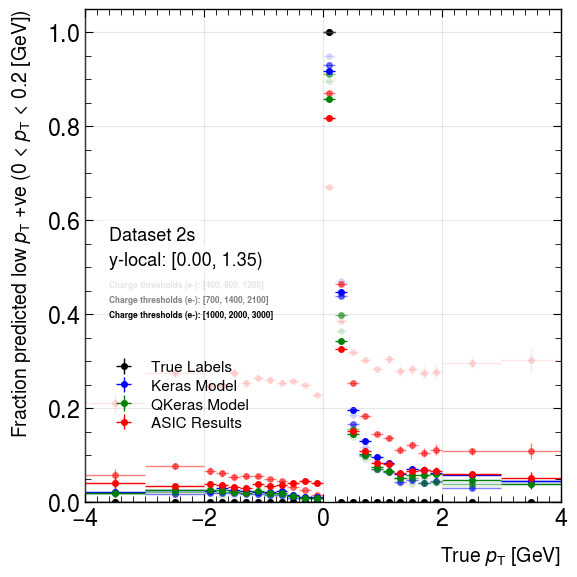

[-14.930747922437673, -15.910941475826972, -16.022068965517242, -15.958543983822043, -15.826241134751774, -15.99566265060241, -15.716582316165525, -15.763047285464099, -15.672295852928602, -15.589477654158024, -15.361982382481271, -15.366938041869316, -17.475253333333335, -16.51001604212085, -16.230882987245057, -16.200700488219063, -16.102463405926454, -16.244054696789537, -15.949596774193548, -15.886750555144337, -16.025590551181104, -15.94750656167979, -16.082338152105596, -16.183279742765272]
[-1.5900277008310248, -1.645674300254453, -1.6620689655172414, -1.577350859453994, -1.626950354609929, -1.5479518072289156, -1.5989877939863055, -1.5821366024518388, -1.5659469858914066, -1.5393802250298574, -1.5604676051700008, -1.7608902516388243, -2.60688, -1.9116038007486322, -1.7746626409513833, -1.7468690299299512, -1.6774366297750802, -1.6406064209274673, -1.7127016129032258, -1.682457438934123, -1.625, -1.7020997375328084, -1.6637335009428034, -1.6720257234726688]
[0.21329639889196675,

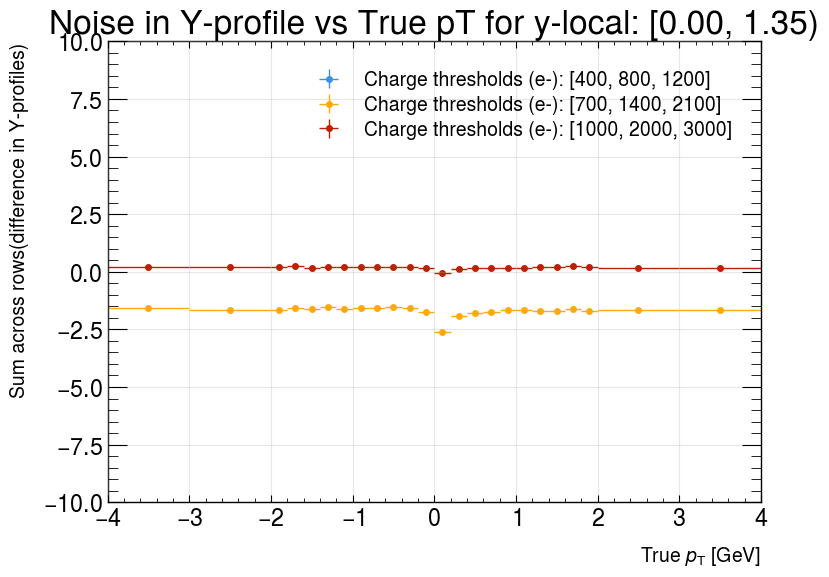

In [5]:
from PyPDF2 import PdfMerger

# Create bins for true pT values from -4 to 4
bins_pos = np.unique(np.concatenate([
    np.linspace(0, 1, 5, endpoint=False),
    np.linspace(1, 2, 5, endpoint=False),
    np.linspace(2, 4, 3, endpoint=True)
]))
bins_neg = -1 * bins_pos[::-1]
pt_bins = np.unique(np.concatenate([bins_neg, bins_pos]))
bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
bin_widths = np.diff(pt_bins)

# binNumberList = range(len(bins) - 1) # full range
binNumberList = [6] # just the 0th bin, as chosen by Giuseppe
label_names = [r'high $p_{\mathrm{T}}$ (abs($p_{\mathrm{T}}$) > 0.2 [GeV])', r'low $p_{\mathrm{T}}$ -ve (-0.2 < $p_{\mathrm{T}}$ < 0 [GeV])', r'low $p_{\mathrm{T}}$ +ve (0 < $p_{\mathrm{T}}$ < 0.2 [GeV])']  # replace with your label meaning
DNNlabels = [0,1,2]
for bin_number in binNumberList:
    ylocal_min = bins[bin_number]
    ylocal_max = bins[bin_number + 1]
    for iL in DNNlabels:
        fig, ax = plt.subplots(figsize=(6,6))

        ax.text(0.05, 0.56, f"Dataset 2s", transform=ax.transAxes, fontsize=13, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        ax.text(0.05, 0.51, f"y-local: [{ylocal_min:.2f}, {ylocal_max:.2f})", transform=ax.transAxes, fontsize=13, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        # ax.text(0.05, 0.48, f"Label {iL}: {label_names[iL]}", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        for iC, conf in enumerate(confs):
            mask = (conf["ylocals"] >= ylocal_min) & (conf["ylocals"] < ylocal_max)
            n_asic = conf["asic_predictions"].shape[0] # passing same number of events as asic predictions for true/keras/qkeras does not seem to make a big difference, atleast when checked for a run with ~170k events and asic predictions for 150k events.
            true_res_bin = analyzeResults(conf["pt"][mask], pt_bins, conf["clslabels"][mask])
            keras_res_bin = analyzeResults(conf["pt"][mask], pt_bins, conf["keras_predictions"][mask])
            qkeras_res_bin = analyzeResults(conf["pt"][mask], pt_bins, conf["qkeras_predictions"][mask])
            asic_res_bin = analyzeResults(conf["pt"][mask][:conf["asic_predictions"].shape[0]], pt_bins[:conf["asic_predictions"].shape[0]], conf["asic_predictions"])
            noise_yprofile = yprofile_difference(conf["pt"][mask][:conf["asic_predictions"].shape[0]], pt_bins[:conf["asic_predictions"].shape[0]], conf["yprofiles"][mask][:conf["asic_yprofiles"].shape[0]], conf["asic_yprofiles"])
            conf["noise_yprofile"] = noise_yprofile
            print(f"")
            print("Dataset: ",conf["qm_charge_levels"],", size of asic results = ", conf["asic_predictions"].shape, ", total size of dataset = ", mask.sum())
            # return np.array(acc0), np.array(acc0_errs), np.array(acc1), np.array(acc1_errs), np.array(acc2), np.array(acc2_errs), signal_efficiency, background_rejection, data_reduction
            print(f"Truth level signal efficiency = {true_res_bin[2*len(DNNlabels)] * 100:.2f}%, background rejection = {true_res_bin[2*len(DNNlabels)+1] * 100:.2f}%, data reduction = {true_res_bin[2*len(DNNlabels)+1] * 100:.2f}%")
            print(f"Keras signal efficiency = {keras_res_bin[2*len(DNNlabels)] * 100:.2f}%, background rejection = {keras_res_bin[2*len(DNNlabels)+1] * 100:.2f}%, data reduction = {keras_res_bin[2*len(DNNlabels)+1] * 100:.2f}%")
            print(f"QKeras signal efficiency = {qkeras_res_bin[2*len(DNNlabels)] * 100:.2f}%, background rejection = {qkeras_res_bin[2*len(DNNlabels)+1] * 100:.2f}%, data reduction = {qkeras_res_bin[2*len(DNNlabels)+1] * 100:.2f}%")
            
            print(f"ASIC signal efficiency = {asic_res_bin[2*len(DNNlabels)] * 100:.2f}%, background rejection = {asic_res_bin[2*len(DNNlabels)+1] * 100:.2f}%, data reduction = {asic_res_bin[2*len(DNNlabels)+1] * 100:.2f}%")
            noise_threshold = conf["qm_charge_levels"]
            noise_key = ",".join(map(str, noise_threshold))
            json_path = "performance_vs_noise-threshold.json"
            signal_eff = asic_res_bin[2*len(DNNlabels)] * 100
            bkg_rej = asic_res_bin[2*len(DNNlabels)+1] * 100
            data_red = asic_res_bin[2*len(DNNlabels)+1] * 100
            result = {
                "signal_efficiency": signal_eff,
                "background_rejection": bkg_rej,
                "data_reduction": data_red
            }

            # Load existing results if file exists
            if os.path.exists(json_path):
                with open(json_path, "r") as f:
                    all_results = json.load(f)
            else:
                all_results = {}

            # Overwrite or add results for this noise threshold
            # Update only the three metrics, preserve other keys
            if noise_key in all_results:
                all_results[noise_key].update({
                    "signal_efficiency": signal_eff,
                    "background_rejection": bkg_rej,
                    "data_reduction": data_red
                })
            else:
                all_results[noise_key] = result
            with open(json_path, "w") as f:
                json.dump(all_results, f, indent=2)

            # plot settings
            light2 = (conf["qm_charge_levels"] == [400, 800, 1200])
            light = (conf["qm_charge_levels"] == [700, 1400, 2100])
            dark = (conf["qm_charge_levels"] == [1000, 2000, 3000])
            alpha = 1
            if light2: alpha = 0.1  # make the first configuration more transparent
            if light: alpha = 0.5  # make the second configuration more transparent
            # alpha = conf["qm_charge_levels"][0]/1000
            # if conf["qm_charge_levels"][0]==400: alpha = 1
            labels = [ "True Labels", "Keras Model", "QKeras Model", "ASIC Results"]
            if not dark:
                labels = ["" for _ in labels]  # hide labels for the first configuration

            # get accuracy and error for label iL
            ax.errorbar(bin_centers, true_res_bin[2*iL], xerr=bin_widths/2, yerr=true_res_bin[2*iL+1], fmt='o', linewidth=1, markersize=4, color="black", label=labels[0], alpha=alpha)
            ax.errorbar(bin_centers, keras_res_bin[2*iL], xerr=bin_widths/2, yerr=keras_res_bin[2*iL+1], fmt='o', linewidth=1, markersize=4, color="blue", label=labels[1], alpha=alpha)
            ax.errorbar(bin_centers, qkeras_res_bin[2*iL], xerr=bin_widths/2, yerr=qkeras_res_bin[2*iL+1], fmt='o', linewidth=1, markersize=4, color="green", label=labels[2], alpha=alpha)
            ax.errorbar(bin_centers, asic_res_bin[2*iL], xerr=bin_widths/2, yerr=asic_res_bin[2*iL+1], fmt='o', linewidth=1, markersize=4, color="red", label=labels[3], alpha=alpha)
            ax.text(0.05, 0.45 - iC*0.03, f"Charge thresholds (e-): {conf['qm_charge_levels']}", transform=ax.transAxes, fontsize=6, verticalalignment='top', fontweight='bold', alpha=alpha)

        ax.set_xlabel(r'True $p_{\mathrm{T}}$ [GeV]')
        ax.set_ylabel(f'Fraction predicted {label_names[iL]}')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(-4, 4)
        ax.tick_params(which='minor', length=4)
        ax.tick_params(which='major', length=6)
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.yaxis.set_minor_locator(MultipleLocator(0.05))

        ax.legend(loc='lower left', fontsize=11, bbox_to_anchor=(0, 0.1))
        plt.tight_layout()
        plt.show()

        # os.makedirs(f"plots", exist_ok=True)
        pdf_filename = f"{save_dir}/eff_vs_pt_ylocal_bin_{bin_number}_label_{iL}_{suffix}.pdf"
        fig.savefig(pdf_filename)

    plt.figure(2)
    for iC, conf in enumerate(confs):
        print(conf["noise_yprofile"])
        plt.errorbar(bin_centers, conf["noise_yprofile"], xerr=bin_widths/2, yerr=0, label=f"Charge thresholds (e-): {conf['qm_charge_levels']}", fmt='o', linewidth=1, markersize=4)
    plt.xlabel(r'True $p_{\mathrm{T}}$ [GeV]')
    plt.ylabel("Sum across rows(difference in Y-profiles)")
    plt.grid(True, alpha=0.3)
    plt.ylim(-10,10)
    plt.title(f"Noise in Y-profile vs True pT for y-local: [{ylocal_min:.2f}, {ylocal_max:.2f})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/noise_in_yprofile_ylocal_bin_{bin_number}_{suffix}.pdf")

# After the loop, concatenate all PDFs into one (run this after the loop)
if len(binNumberList) > 1:
    merger = PdfMerger()
    pdf_files = [f"{save_dir}/eff_vs_pt_ylocal_bin_{i}_{suffix}.pdf" for i in binNumberList]
    for pdf in pdf_files:
        merger.append(pdf)
    merger.write(f"{save_dir}/all_eff_vs_pt_ylocal_bins_{suffix}.pdf")
    merger.close()

## Accuracy results of DNN results from  w/ and w/o noise yprofile subsets
The result form the above plot will be referred to as "ASIC Results".
Owing to noise from electronics/chip and charge-injection imperfections, the y-profile sent as input to the DNN might not match the original simulated y-profile. Accuracy results for a subset of data where the injected and simulated y-profiles match are produced and are labeled as "ASIC Results (no noise)".

Bin 6: 169607 entries in ylocal range [0.00, 1.35)
asserting shapes:  (169607, 16) (169607, 16)
Number of events with the same y-profiles (between simulation and injected into ASIC) =  0


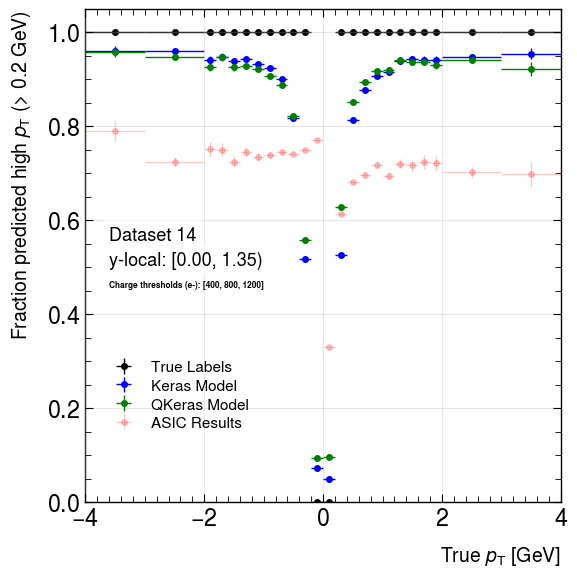

Bin 6: 169607 entries in ylocal range [0.00, 1.35)
asserting shapes:  (169607, 16) (169607, 16)
Number of events with the same y-profiles (between simulation and injected into ASIC) =  11582
(169607,)


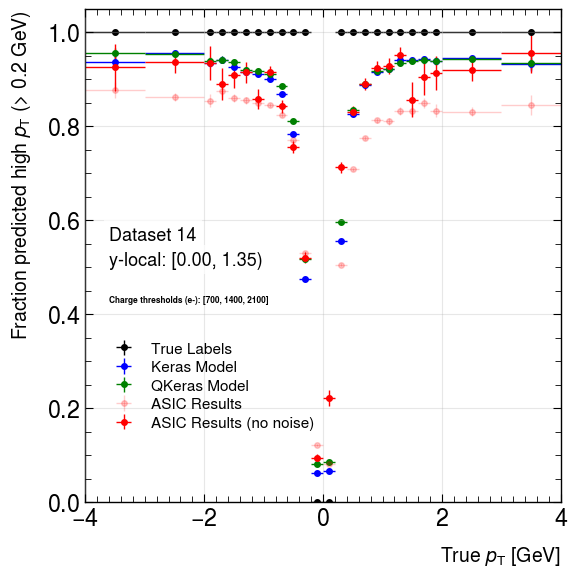

Bin 6: 169607 entries in ylocal range [0.00, 1.35)
asserting shapes:  (169607, 16) (169607, 16)
Number of events with the same y-profiles (between simulation and injected into ASIC) =  94761
(169607,)


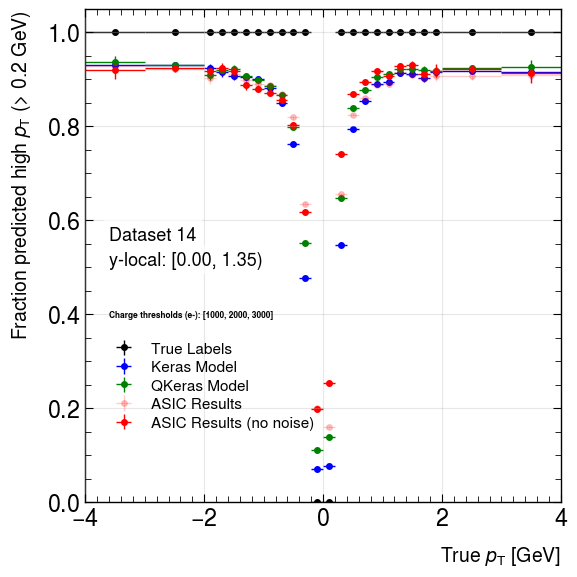

In [6]:
from PyPDF2 import PdfMerger

# Create bins for true pT values from -4 to 4
bins_pos = np.unique(np.concatenate([
    np.linspace(0, 1, 5, endpoint=False),
    np.linspace(1, 2, 5, endpoint=False),
    np.linspace(2, 4, 3, endpoint=True)
]))
bins_neg = -1 * bins_pos[::-1]
pt_bins = np.unique(np.concatenate([bins_neg, bins_pos]))
bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
bin_widths = np.diff(pt_bins)

# binNumberList = range(len(bins) - 1) # full range
binNumberList = [6] # just the 0th bin, as chosen by Giuseppe
# plot per configuration
for iC, conf in enumerate(confs):
    for bin_number in binNumberList:
    
        # Select the range of the i-th bin of ylocal
        ylocal_min = bins[bin_number]
        ylocal_max = bins[bin_number + 1]
        
        # Create the plot
        fig, ax = plt.subplots(figsize=(6,6))

        # Add text for ylocal bin range
        ax.text(0.05, 0.56, f"Dataset 14", transform=ax.transAxes, fontsize=13, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        ax.text(0.05, 0.51, f"y-local: [{ylocal_min:.2f}, {ylocal_max:.2f})", transform=ax.transAxes, fontsize=13, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    

    # interested_range = (ylocal_min, ylocal_max)
    mask = (conf["ylocals"] >= ylocal_min) & (conf["ylocals"] < ylocal_max)
    print(f"Bin {bin_number}: {mask.sum()} entries in ylocal range [{ylocal_min:.2f}, {ylocal_max:.2f})")
    
    # Find number of events with the same intended and injected input to the DNN (y-profile)
    print("asserting shapes: ", (conf["yprofiles"][mask]).shape, conf["asic_yprofiles"].shape)
    mask_noNoiseInjected = np.all(conf["yprofiles"][mask][:conf["asic_predictions"].shape[0]] == conf["asic_yprofiles"], axis=1)
    print("Number of events with the same y-profiles (between simulation and injected into ASIC) = ", mask_noNoiseInjected.sum())
    
    # results
    true_res_bin = analyzeResults(conf["pt"][mask], pt_bins, conf["clslabels"][mask])
    keras_res_bin = analyzeResults(conf["pt"][mask], pt_bins, conf["keras_predictions"][mask])
    qkeras_res_bin = analyzeResults(conf["pt"][mask], pt_bins, conf["qkeras_predictions"][mask])
    asic_res_bin = analyzeResults(conf["pt"][mask][:conf["asic_predictions"].shape[0]], pt_bins[:conf["asic_predictions"].shape[0]], conf["asic_predictions"])

    if(mask_noNoiseInjected.sum() != 0):
        conf["asic_predictions_yprofileMatch"] = conf["asic_predictions"][mask_noNoiseInjected][:mask_noNoiseInjected.sum()]
        conf["pt_inYrange"] = conf["pt"][mask][:mask.sum()]
        print(conf["pt_inYrange"].shape)
        asic_noNoiseInjected_res_bin = analyzeResults(conf["pt_inYrange"][mask_noNoiseInjected][:mask_noNoiseInjected.sum()], pt_bins, conf["asic_predictions_yprofileMatch"])

    # plot settings
    # light = (conf["qm_charge_levels"] == [400, 1600, 2400])
    alpha = 1.0 #0.2 if light else 1.0  # make the first configuration more transparent
    labels = [ "True Labels", "Keras Model", "QKeras Model", "ASIC Results", "ASIC Results (no noise)"]
    # if light:
    #     labels = ["" for _ in labels]  # hide labels for the first configuration
    
    # plot error bars
    ax.errorbar(bin_centers, true_res_bin[0], xerr=bin_widths/2, yerr=true_res_bin[1], fmt='o', linewidth=1, markersize=4, color="black", label=labels[0], alpha=alpha)
    ax.errorbar(bin_centers, keras_res_bin[0], xerr=bin_widths/2, yerr=keras_res_bin[1], fmt='o', linewidth=1, markersize=4, color="blue", label=labels[1], alpha=alpha)
    ax.errorbar(bin_centers, qkeras_res_bin[0], xerr=bin_widths/2, yerr=qkeras_res_bin[1], fmt='o', linewidth=1, markersize=4, color="green", label=labels[2], alpha=alpha)
    ax.errorbar(bin_centers, asic_res_bin[0], xerr=bin_widths/2, yerr=asic_res_bin[1], fmt='o', linewidth=1, markersize=4, color="red", label=labels[3], alpha=0.2)
    if(mask_noNoiseInjected.sum() != 0):
        ax.errorbar(bin_centers, asic_noNoiseInjected_res_bin[0], xerr=bin_widths/2, yerr=asic_noNoiseInjected_res_bin[1], fmt='o', linewidth=1, markersize=4, color="red", label=labels[4], alpha=alpha)

    ax.text(0.05, 0.45 - iC*0.03, f"Charge thresholds (e-): {conf['qm_charge_levels']}", transform=ax.transAxes, fontsize=6, verticalalignment='top', fontweight='bold', alpha=alpha)


    # set plot styles
    ax.set_xlabel(r'True $p_{\mathrm{T}}$ [GeV]')
    ax.set_ylabel(r'Fraction predicted high $p_{\mathrm{T}}$ (> 0.2 GeV)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-4, 4)
    ax.tick_params(which='minor', length=4)
    ax.tick_params(which='major', length=6)
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))

    ax.legend(loc='lower left', fontsize=11, bbox_to_anchor=(0, 0.1))
    plt.tight_layout()
    plt.show()

    # # Create 'plots' directory if it doesn't exist
    # os.makedirs("plots", exist_ok=True)

    # Save the current figure as a PDF in the 'plots' directory
    pdf_filename = f'{save_dir}/noisyAndNoNoise_{conf["qm_charge_levels"][0]}e-Thresh_eff_vs_pt_ylocal_bins_{suffix}.pdf'
    fig.savefig(pdf_filename)

    # # After the loop, concatenate all PDFs into one (run this after the loop)
    # if len(binNumberList) > 1:
    #     merger = PdfMerger()
    #     pdf_files = [f"plots/eff_vs_pt_ylocal_bin_{i}.pdf" for i in binNumberList]
    #     for pdf in pdf_files:
    #         merger.append(pdf)
    #     merger.write(f'plots/noisyAndNoNoise_{conf["qm_charge_levels"][0]}e-Thresh_eff_vs_pt_ylocal_bins.pdf')
    #     merger.close()
